In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/parkinson.csv')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [3]:
df.shape

(1000, 24)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1000 non-null   str    
 1   MDVP:Fo(Hz)       1000 non-null   float64
 2   MDVP:Fhi(Hz)      1000 non-null   float64
 3   MDVP:Flo(Hz)      1000 non-null   float64
 4   MDVP:Jitter(%)    1000 non-null   float64
 5   MDVP:Jitter(Abs)  1000 non-null   float64
 6   MDVP:RAP          1000 non-null   float64
 7   MDVP:PPQ          1000 non-null   float64
 8   Jitter:DDP        1000 non-null   float64
 9   MDVP:Shimmer      1000 non-null   float64
 10  MDVP:Shimmer(dB)  1000 non-null   float64
 11  Shimmer:APQ3      1000 non-null   float64
 12  Shimmer:APQ5      1000 non-null   float64
 13  MDVP:APQ          1000 non-null   float64
 14  Shimmer:DDA       1000 non-null   float64
 15  NHR               1000 non-null   float64
 16  HNR               1000 non-null   float64
 17  status 

In [5]:
df.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [6]:
df['status'].value_counts()

status
1    541
0    459
Name: count, dtype: int64

In [7]:
X = df.drop(columns=['name', 'status'])
y = df['status']
groups = df['name']

In [8]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score

splitter = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

In [9]:
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [11]:
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train class balance: {y_train.mean():.3f}, Test class balance: {y_test.mean():.3f}")

Train size: 799, Test size: 201
Train class balance: 0.552, Test class balance: 0.498


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1: {f1_score(y_test, y_pred_knn):.4f}")


Accuracy: 0.5622
Precision: 0.5429
Recall: 0.7600
F1: 0.6333


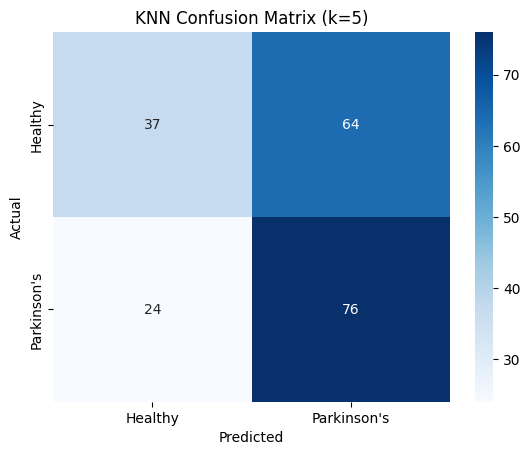

In [17]:
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', "Parkinson's"], yticklabels=['Healthy', "Parkinson's"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("KNN Confusion Matrix (k=5)")
plt.show()

In [18]:
gkf = GroupKFold(n_splits=5)
scores_knn = cross_val_score(knn, scaler.fit_transform(X), y, cv=gkf, groups=groups, scoring='recall')
print(f"\nCV Recall scores: {scores_knn}")
print(f"Mean: {scores_knn.mean():.4f}, Std: {scores_knn.std():.4f}")


CV Recall scores: [0.75471698 0.75       0.72727273 0.78431373 0.77669903]
Mean: 0.7586, Std: 0.0203
